In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import jax.numpy as jnp
from scipy.optimize import minimize

sys.path.append("..")

from src.data import load_data
from src.visualisation import (
    plot_hole_locations,
    plot_model_predictions,
    plot_sectioned_model,
)
from src.model import (
    SectionedModel,
    IdealModel,
    setup_optimization
)
from src.bootstrap import (
    bootstrap_parameter_uncertainty,
    save_bootstrap_results
)


# Set plot style
plt.style.use('mystyle.mplstyle')

# Path to the data file
data_file = '../data/1-Fragment_C_Hole_Measurements.csv'
data = load_data(data_file)

## 1. Initial Values from Ideal Model

Let's fit the ideal model first to obtain good initial values for $N, r, \sigma (\sigma_r, \sigma_t), x_{0j}, y_{0j}, \alpha_j$.


In an ideal, undamaged ring with $N$ holes, the holes would be arranged in a perfect circle with radius $r$. The angular position of the $i$-th hole (where $i = 1, 2, \ldots, N$) would be:

$$\theta_i = 2\pi \frac{(i-1)}{N} + \theta_0$$

And its Cartesian coordinates would be:

$$x_i = x_0 + r \cos(\theta_i)$$
$$y_i = y_0 + r \sin(\theta_i)$$

where $(x_0, y_0)$ is the center of the ring.

We only employ the isotropic covariance assumption here for convenience. 


### 1.1 Minimise NLL

In [2]:
model_ideal = IdealModel(data)
n_sections = model_ideal.n_sections

# Optimisition objective
nll_ideal, grad_nll_ideal = setup_optimization(model_ideal, 'isotropic')

# Initial values & bounds
# N, r, sigma, x0, y0, theta0
initial_vec_ideal = [360.0, 80.0, 5, 0, 0, 0]
bounds_ideal = [(200, 400), (0, None), (0, None), (None, None), (None, None), (jnp.pi, 2*jnp.pi)]
result_ideal = minimize(
    fun=nll_ideal,
    x0=initial_vec_ideal,
    bounds=bounds_ideal,
    method='trust-constr', # L-BFGS-B is not working based on my intials and bounds
    jac=grad_nll_ideal
)
print(f"Final NLL value: {result_ideal.fun:.4f}")

Final NLL value: -77.1133


/Users/clementine/mphildis/coursework/S2/xl628/..venv/lib/python3.11/site-packages/scipy/optimize/_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


### 1.2 Bootstrap Uncertainty

In [3]:
bootstrap_results_ideal = bootstrap_parameter_uncertainty(
    original_data=data,
    model_class=IdealModel,
    model_type='isotropic', # or 'radial_tangential'
    mle_result=result_ideal,
    n_bootstrap_samples=100,
    resample_within_sections=False, # False for IdealModel
    minimize_method='trust-constr', # Match the method used for MLE
    bounds=bounds_ideal, # Pass the same bounds
)

param_names = ["N", "r", "sigma", "x0", "y0", "theta0"]

save_bootstrap_results(
    bootstrap_results_ideal,
    param_names,
    output_file='results/bootstrap_results_ideal.csv',
    model_class_name='IdealModel',
    model_type='isotropic',
    confidence_levels=[0.68, 0.90, 0.95, 0.99],
    save_all_samples=True
)

result_with_uncertainty_ideal = pd.read_csv('results/bootstrap_results_ideal.csv')
result_with_uncertainty_ideal

Bootstrap Progress:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 1.3 Visualisation

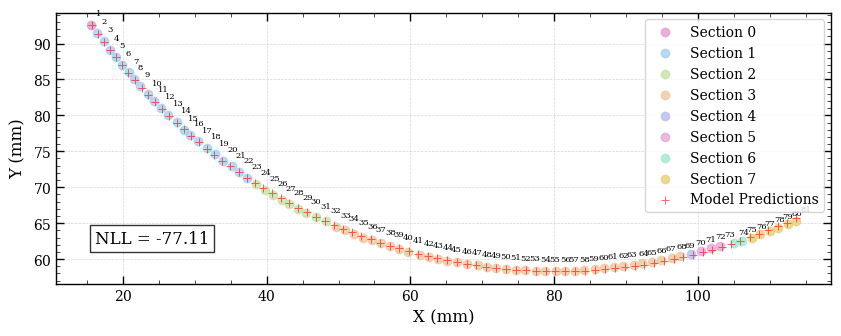

In [7]:
ax = plot_hole_locations(data=data)
plot_model_predictions(data, model_ideal.vec_to_params_isotropic(result_ideal.x), model_ideal, ax=ax)
plt.annotate(f'NLL = {result_ideal.fun:.2f}', 
             xy=(0.05, 0.15), 
             xycoords='axes fraction',
             bbox=dict(boxstyle="square,pad=0.3", fc="white", alpha=0.8))
plt.savefig('figures/ml_ideal_model.pdf')

Employing the ideal model with isotropic errors looks quite good.

## 2. Isotropic Model

We will use the estimates obtained from the ideal model as our initial values to fit the sectioned model 

### 2.1 Minimise NLL

In [9]:
N, r, sigma, x0, y0, theta0 = result_ideal.x # (better than random initial values)
model = SectionedModel(data)
n_sections = model.n_sections

# Isotropic
neg_log_likelihood, grad_neg_log_likelihood = setup_optimization(model, 'isotropic')

# Initial values & bounds
initial_vec_isotropic = np.concatenate([[N, r, sigma], np.tile([x0, y0, theta0], n_sections)])
# bounds_isotropic = (
#     [(200, 400), (0, None), (0, None)] + 
#     [(x0, x0), (y0, y0), (theta0, theta0)] +  # fix sections 0 and 4
#     [(None, None)] * 3 * 3 +
#     [(x0, x0), (y0, y0), (theta0, theta0)] +  # fix sections 0 and 4
#     [(None, None)] * 3 * 3
# )
bounds_isotropic = [(200, 400), (0, None), (0, None)] + [(None, None)] * 3 * n_sections
result_isotropic = minimize(
    fun=neg_log_likelihood,
    x0=initial_vec_isotropic,
    bounds=bounds_isotropic,
    method='L-BFGS-B',
    jac=grad_neg_log_likelihood,
    options={'disp': True}
)

### 2.2 Bootstrap Uncertainty

In [10]:
bootstrap_results_ideal = bootstrap_parameter_uncertainty(
    original_data=data,
    model_class=SectionedModel,
    model_type='isotropic', # or 'radial_tangential'
    mle_result=result_isotropic, # Start from original MLE
    n_bootstrap_samples=100,
    resample_within_sections=True, # False for IdealModel
    minimize_method='L-BFGS-B', # Match the method used for MLE
    bounds=bounds_isotropic # Pass the same bounds
)

param_names = ["N", "r", "sigma"]
for section in model.section_ids_int:
    param_names.extend([f"x0_{section}", f"y0_{section}", f"alpha_{section}"])

save_bootstrap_results(
    bootstrap_results_ideal,
    param_names,
    output_file='results/bootstrap_results_isotropic.csv',
    model_class_name='SectionedModel',
    model_type='isotropic',
    confidence_levels=[0.68, 0.90, 0.95, 0.99],
    save_all_samples=True
)

result_with_uncertainty_isotropic = pd.read_csv('results/bootstrap_results_isotropic.csv')
result_with_uncertainty_isotropic

Bootstrap Progress: 100%|██████████| 100/100 [02:51<00:00,  1.72s/it]

Bootstrap finished. 92 successful samples out of 100.
All bootstrap samples saved to results/bootstrap_results_isotropic_samples.csv
Bootstrap results saved to results/bootstrap_results_isotropic.csv


,Parameter,Mean,Median,Std,68.0%_lower,68.0%_upper,90.0%_lower,90.0%_upper,95.0%_lower,95.0%_upper,99.0%_lower,99.0%_upper
0,N,357.399115,357.395255,0.010221,357.395037,357.402982,357.394927,357.413938,357.394317,357.418411,357.392678,357.455390
1,r,77.920925,77.923109,0.007714,77.915256,77.925933,77.903987,77.931161,77.900117,77.932035,77.897168,77.932896
2,sigma,0.086602,0.086074,0.004711,0.081640,0.091395,0.079384,0.095241,0.078481,0.096055,0.076022,0.097121
3,x0_0,80.095453,80.096901,0.003373,80.093518,80.097153,80.090262,80.097232,80.089685,80.097234,80.078737,80.097250
4,y0_0,136.371224,136.372207,0.002290,136.369910,136.372378,136.367700,136.372431,136.367308,136.372432,136.359878,136.372443
5,alpha_0,3.737889,3.737893,0.000027,3.737859,3.737908,3.737848,3.737927,3.737834,3.737940,3.737826,3.737969
6,x0_1,80.102349,80.107755,0.009122,80.092510,80.109459,80.083949,80.109575,80.082560,80.109779,80.075634,80.109990
7,y0_1,136.467116,136.472534,0.008982,136.456482,136.473853,136.450447,136.474019,136.444337,136.474381,136.441212,136.476459
8,alpha_1,3.741151,3.741143,0.000384,3.740773,3.741558,3.740510,3.741791,3.740376,3.741887,3.740242,3.742040
9,x0_2,80.234498,80.236077,0.006074,80.232482,80.236404,80.221424,80.241317,80.220721,80.242205,80.208602,80.249387


### 2.3 Visualisation

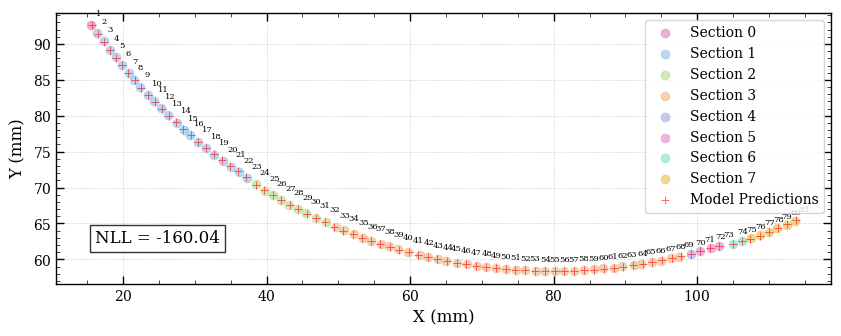

In [11]:
ax = plot_hole_locations(data=data)
plot_model_predictions(
    data=data, 
    params=model.vec_to_params_isotropic(result_isotropic.x), 
    model=model, 
    ax=ax
)
plt.annotate(f'NLL = {result_isotropic.fun:.2f}', 
             xy=(0.05, 0.15), 
             xycoords='axes fraction',
             bbox=dict(boxstyle="square,pad=0.3", fc="white", alpha=0.8))
plt.savefig('figures/ml_isotropic_model.pdf')

(Even though NLL is lower, it does not account for model complexity.)

## 3. Radial/Tangential Model
Again, we the estimates obtained from the ideal model
### 3.1 Minimise NLL

In [12]:
N, r, sigma, x0, y0, theta0 = result_ideal.x # (better than random initial values)
model = SectionedModel(data)
n_sections = model.n_sections

# Isotropic
neg_log_likelihood, grad_neg_log_likelihood = setup_optimization(model, 'radial_tangential')

# Initial values & bounds
initial_vec_radial_tangential = np.concatenate([[N, r, sigma, sigma], np.tile([x0, y0, theta0], n_sections)])
# bounds_radial_tangential = (
#     [(200, 400), (0, None), (0, None), (0, None)] + 
#     [(x0, x0), (y0, y0), (theta0, theta0)] +  # fix sections 0 and 4
#     [(None, None)] * 3 * 3 + 
#     [(x0, x0), (y0, y0), (theta0, theta0)] +  # fix sections 0 and 4
#     [(None, None)] * 3 * 3
# )
bounds_radial_tangential = [(200, 400), (0, None), (0, None), (0, None)] + [(None, None)] * 3 * n_sections
result_radial_tangential = minimize(
    fun=neg_log_likelihood,
    x0=initial_vec_radial_tangential,
    bounds=bounds_radial_tangential,
    method='L-BFGS-B',
    jac=grad_neg_log_likelihood,
    options={'disp': True}
)

### 3.2 Bootstrap Uncertainty

In [13]:
bootstrap_results_radial_tangential = bootstrap_parameter_uncertainty(
    original_data=data,
    model_class=SectionedModel,
    model_type='radial_tangential',
    mle_result=result_radial_tangential,
    n_bootstrap_samples=100,
    resample_within_sections=True,
    minimize_method='L-BFGS-B',
    bounds=bounds_radial_tangential
)

param_names = ["N", "r", "sigma_r", "sigma_t"]
for section in model.section_ids_int:
    param_names.extend([f"x0_{section}", f"y0_{section}", f"alpha_{section}"])

save_bootstrap_results(
    bootstrap_results_radial_tangential,
    param_names,
    output_file='results/bootstrap_results_radial_tangential.csv',
    model_class_name='SectionedModel',
    model_type='radial_tangential',
    confidence_levels=[0.68, 0.90, 0.95, 0.99],
    save_all_samples=True
)
result_with_uncertainty_radial_tangential = pd.read_csv('results/bootstrap_results_radial_tangential.csv')
result_with_uncertainty_radial_tangential

Bootstrap Progress: 100%|██████████| 100/100 [06:01<00:00,  3.62s/it]

Bootstrap finished. 90 successful samples out of 100.
All bootstrap samples saved to results/bootstrap_results_radial_tangential_samples.csv
Bootstrap results saved to results/bootstrap_results_radial_tangential.csv


,Parameter,Mean,Median,Std,68.0%_lower,68.0%_upper,90.0%_lower,90.0%_upper,95.0%_lower,95.0%_upper,99.0%_lower,99.0%_upper
0,N,357.277197,357.268049,0.034815,357.267325,357.271735,357.266451,357.324371,357.262973,357.391511,357.260285,357.469879
1,r,77.846543,77.853888,0.029612,77.848668,77.857046,77.807500,77.858293,77.726003,77.859363,77.693837,77.860454
2,sigma_r,0.025016,0.024975,0.002360,0.022771,0.027655,0.021283,0.028978,0.020777,0.029406,0.019473,0.029935
3,sigma_t,0.116269,0.116586,0.007824,0.109472,0.123821,0.102745,0.127563,0.098723,0.128701,0.091307,0.132224
4,x0_0,80.011572,80.017769,0.024281,80.014144,80.018864,79.980911,80.021029,79.911639,80.021341,79.886539,80.022377
5,y0_0,136.314292,136.318498,0.016480,136.316038,136.319242,136.293482,136.320711,136.246467,136.320923,136.229430,136.321626
6,alpha_0,3.737892,3.737894,0.000013,3.737880,3.737901,3.737870,3.737914,3.737863,3.737921,3.737856,3.737925
7,x0_1,80.046311,80.057057,0.044023,80.018914,80.064652,79.959777,80.106844,79.913453,80.114706,79.876307,80.131416
8,y0_1,136.399255,136.399412,0.030075,136.387632,136.416277,136.344912,136.450865,136.328088,136.464744,136.302589,136.482054
9,alpha_1,3.741030,3.741034,0.000711,3.740315,3.741625,3.739982,3.742185,3.739505,3.742279,3.739034,3.742610


### 3.3 Visualisation

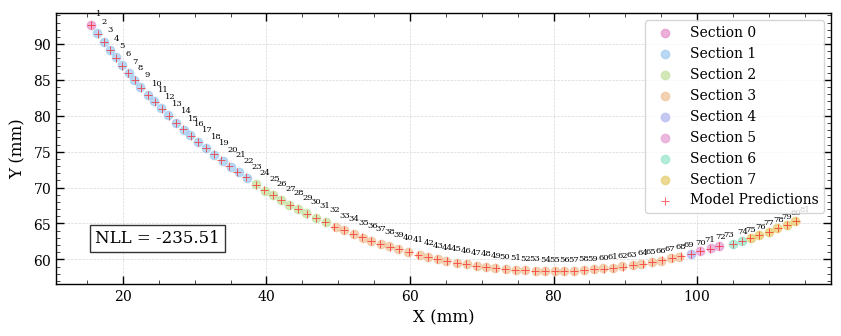

In [14]:
ax = plot_hole_locations(data=data)
plot_model_predictions(
    data=data, 
    params=model.vec_to_params_radial_tangential(result_radial_tangential.x), 
    model=model, 
    ax=ax
)
plt.annotate(f'NLL = {result_radial_tangential.fun:.2f}', 
             xy=(0.05, 0.15), 
             xycoords='axes fraction',
             bbox=dict(boxstyle="square,pad=0.3", fc="white", alpha=0.8))
plt.savefig('figures/ml_radial_tangential_model.pdf')